# Medical Insurance Cost Prediction Using Machine learning
### Name: Alka Singh
### M.Sc. Statistics,IIT Kanpur

In [2]:
# ==========================
# Import Required Libraries
# ==========================

# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Machine Learning Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Model evaluation
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)
from sklearn.pipeline import Pipeline

# Hyperparameter tuning
from sklearn.model_selection import GridSearchCV

# Save the trained model
import joblib

In [3]:
# ==========================
# Load the Dataset
# ==========================

df = pd.read_csv("insurance.csv")

# Display the first 5 rows
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
# ==========================
# Explore the Dataset
# ==========================

# Display first 5 rows
print("First 5 Rows:")
display(df.head())

# Display last 5 rows
print("Last 5 Rows:")
display(df.tail())

# Shape of the dataset
print("\nShape of Dataset:")
print(df.shape)

# Dataset information
print("\nDataset Information:")
df.info()

# Statistical summary
print("\nStatistical Summary:")
display(df.describe())


First 5 Rows:


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


Last 5 Rows:


,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603



Shape of Dataset:
(1338, 7)

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB

Statistical Summary:


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [5]:
# ==========================
# Remove Duplicate Rows
# ==========================

# Remove duplicate rows
df = df.drop_duplicates()

# Verify that duplicates have been removed
print("Duplicate Rows After Removal:")
print(df.duplicated().sum())

# Check the new shape of the dataset
print("\nUpdated Shape:")
print(df.shape)

Duplicate Rows After Removal:
0

Updated Shape:
(1337, 7)


In [6]:
# ==========================
# Data Preprocessing
# ==========================

# Check for missing values
print("Missing Values:\n")
print(df.isnull().sum())

# Check for duplicate rows
print("\nNumber of Duplicate Rows:")
print(df.duplicated().sum())


Missing Values:

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Number of Duplicate Rows:
0


In [7]:
# ==========================
# Remove Duplicate Rows
# ==========================

# Remove duplicate rows
df = df.drop_duplicates()

# Verify that duplicates have been removed
print("Duplicate Rows After Removal:")
print(df.duplicated().sum())

# Check the new shape of the dataset
print("\nUpdated Shape:")
print(df.shape)

Duplicate Rows After Removal:
0

Updated Shape:
(1337, 7)


# 4. Exploratory Data Analysis (EDA)

The objective of Exploratory Data Analysis (EDA) is to understand the structure of the dataset, identify patterns, detect outliers, examine relationships between variables, and gain insights before building machine learning models.

## 4.1 Distribution of Insurance Charges

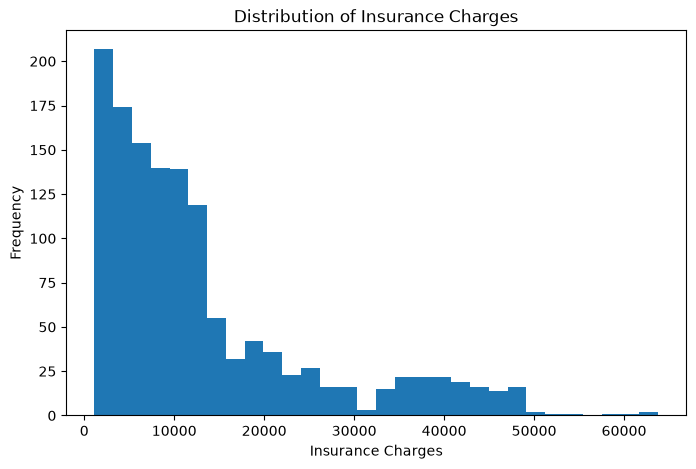

In [33]:
# Distribution of Insurance Charges

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(df["charges"], bins=30)

plt.title("Distribution of Insurance Charges")
plt.xlabel("Insurance Charges")
plt.ylabel("Frequency")

plt.show()

### Observation

- The distribution of insurance charges is positively (right) skewed.
- Most individuals have relatively low insurance charges, while a smaller number have very high charges.
- This indicates that the target variable is not normally distributed.

## 4.2 Age Distribution

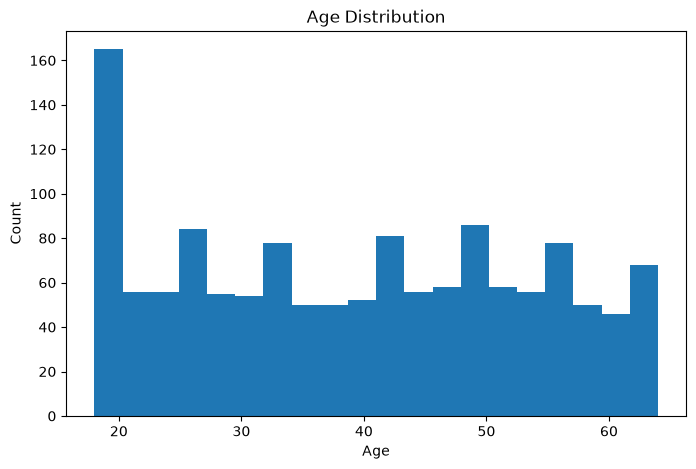

In [34]:
# Age Distribution

plt.figure(figsize=(8,5))

plt.hist(df["age"], bins=20)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

### Observation

- The ages are reasonably distributed across the available age range.
- There is no major imbalance toward any specific age group.

## 4.3 BMI Distribution

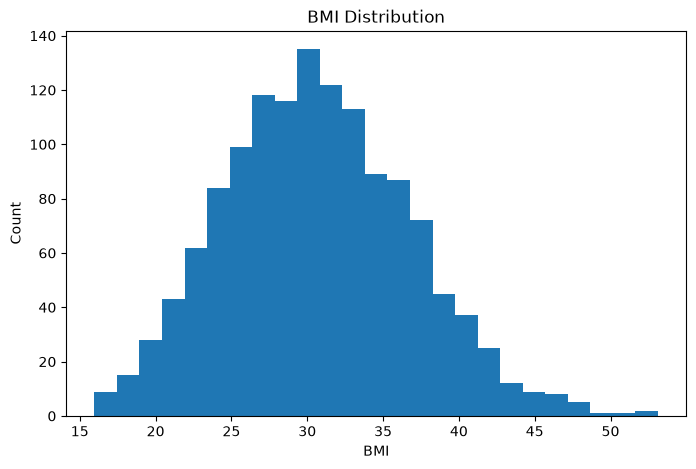

In [35]:
# BMI Distribution

plt.figure(figsize=(8,5))

plt.hist(df["bmi"], bins=25)

plt.title("BMI Distribution")
plt.xlabel("BMI")
plt.ylabel("Count")

plt.show()

### Observation

- Most BMI values lie in the moderate range.
- A few individuals have relatively high BMI values, indicating possible outliers.

In [ ]:
## 4.4 Insurance Charges by Smoking Status

<Figure size 600x500 with 0 Axes>

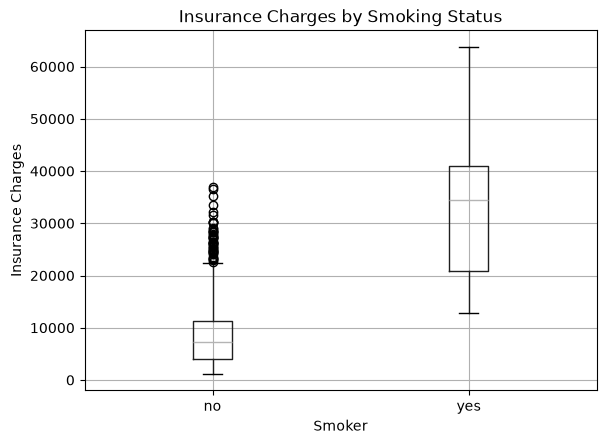

In [36]:
# Charges by Smoking Status

plt.figure(figsize=(6,5))

df.boxplot(column="charges", by="smoker")

plt.title("Insurance Charges by Smoking Status")
plt.suptitle("")

plt.xlabel("Smoker")
plt.ylabel("Insurance Charges")

plt.show()

### Observation

- Smokers have significantly higher insurance charges than non-smokers.
- The smoker group also shows greater variability in charges.
- This suggests that smoking status strongly influences medical insurance costs.

## 4.5 Age vs Insurance Charges

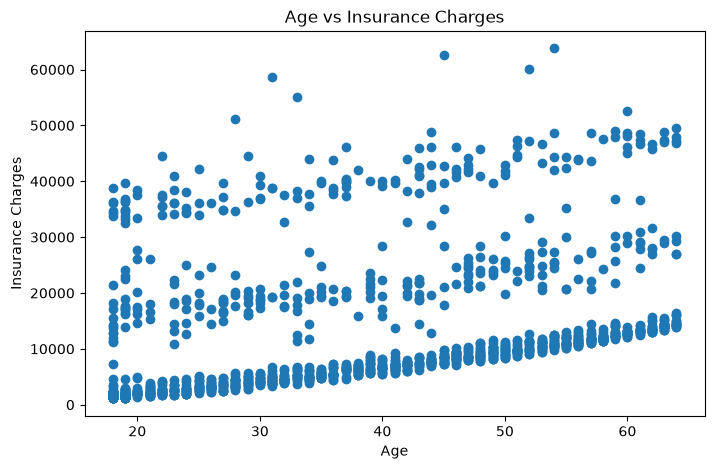

In [37]:
# Age vs Charges

plt.figure(figsize=(8,5))

plt.scatter(df["age"], df["charges"])

plt.title("Age vs Insurance Charges")

plt.xlabel("Age")
plt.ylabel("Insurance Charges")

plt.show()

### Observation

- Insurance charges generally increase with age.
- Older individuals tend to have higher medical insurance costs than younger individuals.

In [ ]:
## 4.6 BMI vs Insurance Charges

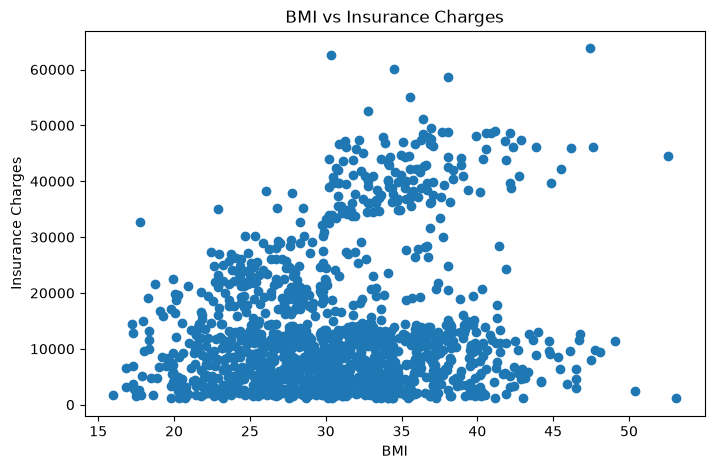

In [38]:
# BMI vs Charges

plt.figure(figsize=(8,5))

plt.scatter(df["bmi"], df["charges"])

plt.title("BMI vs Insurance Charges")

plt.xlabel("BMI")
plt.ylabel("Insurance Charges")

plt.show()

### Observation

- Individuals with higher BMI often have higher insurance charges.
- However, the relationship is not perfectly linear, indicating that other factors also influence medical costs.

## 4.7 Correlation Heatmap

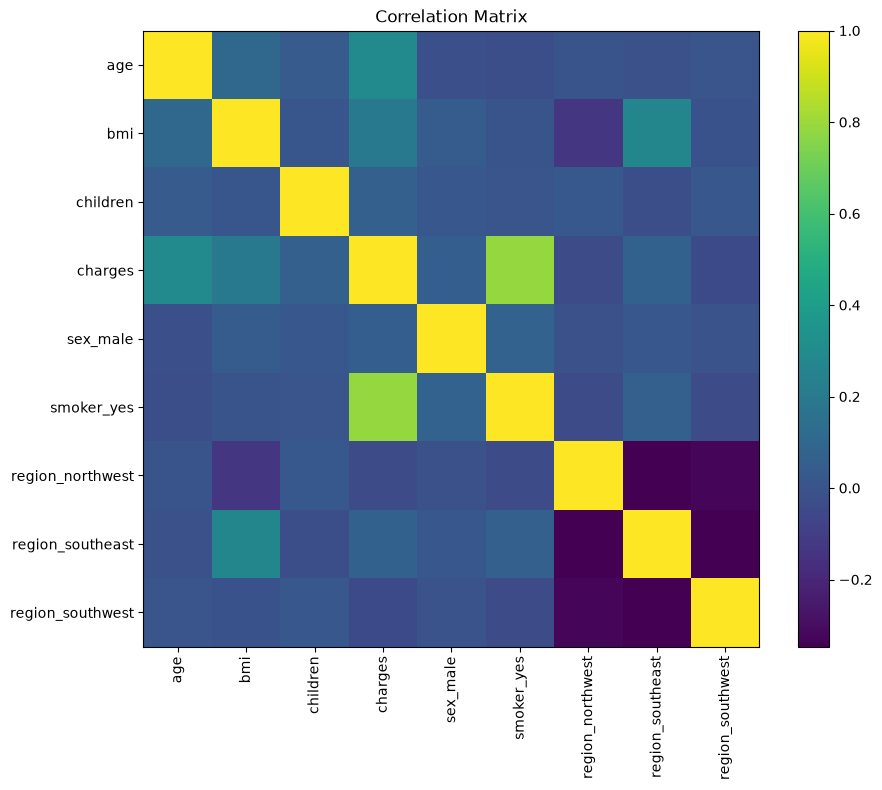

In [39]:
# Correlation Heatmap

import pandas as pd

df_corr = pd.get_dummies(df, drop_first=True)

corr = df_corr.corr()

plt.figure(figsize=(10,8))

plt.imshow(corr)

plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Matrix")

plt.show()

### Observation

- Smoking status shows the strongest positive relationship with insurance charges.
- Age and BMI also exhibit a positive correlation with the target variable.
- Region and sex have relatively weak correlations with insurance charges.

In [31]:

# Features (Independent Variables)
X = df.drop("charges", axis=1)

# Target (Dependent Variable)
y = df["charges"]

print("Features (X):")
display(X.head())

print("Target (y):")
display(y.head())

Features (X):


,age,sex,bmi,children,smoker,region
0,19,female,27.900,0,yes,southwest
1,18,male,33.770,1,no,southeast
2,28,male,33.000,3,no,southeast
3,33,male,22.705,0,no,northwest
4,32,male,28.880,0,no,northwest


Target (y):


0    16884.92400
1     1725.55230
2     4449.46200
3    21984.47061
4     3866.85520
Name: charges, dtype: float64

In [8]:
# ==========================
# Train-Test Split
# ==========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Display the shapes of the datasets
print("Training Features Shape:", X_train.shape)
print("Testing Features Shape :", X_test.shape)

print("Training Target Shape  :", y_train.shape)
print("Testing Target Shape   :", y_test.shape)

Training Features Shape: (1069, 6)
Testing Features Shape : (268, 6)
Training Target Shape  : (1069,)
Testing Target Shape   : (268,)


In [9]:
# ==========================
# Build Preprocessing Pipeline
# ==========================

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Define categorical columns
categorical_features = ["sex", "smoker", "region"]

# Create the preprocessing transformer
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(drop="first", handle_unknown="ignore"),
            categorical_features,
        )
    ],
    remainder="passthrough"
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [10]:
# ==========================
# Multiple Linear Regression Pipeline
# ==========================

# Create the pipeline
lr_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

# Train the model
lr_pipeline.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [11]:
# ==========================
# Evaluate Regression Models
# ==========================

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)
import numpy as np

def evaluate_model(model, X_test, y_test):
    """
    Evaluates a regression model using common regression metrics.
    """

    # Make predictions
    y_pred = model.predict(X_test)

    # Calculate metrics
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)

    # Display results
    print("=" * 40)
    print(f"Model : {model.named_steps['model'].__class__.__name__}")
    print("=" * 40)

    print(f"R² Score : {r2:.4f}")
    print(f"MAE      : {mae:.2f}")
    print(f"MSE      : {mse:.2f}")
    print(f"RMSE     : {rmse:.2f}")

    return {
        "R2": r2,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse
    }

# Evaluate Linear Regression
lr_results = evaluate_model(lr_pipeline, X_test, y_test)

Model : LinearRegression
R² Score : 0.8069
MAE      : 4177.05
MSE      : 35478020.68
RMSE     : 5956.34


In [12]:
# ==========================
# Ridge Regression Pipeline
# ==========================

from sklearn.linear_model import Ridge

# Create Ridge Regression Pipeline
ridge_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", Ridge())
    ]
)

# Train the model
ridge_pipeline.fit(X_train, y_train)

print("Ridge Regression model trained successfully!")

# Evaluate the model
ridge_results = evaluate_model(ridge_pipeline, X_test, y_test)

Ridge Regression model trained successfully!
Model : Ridge
R² Score : 0.8060
MAE      : 4194.01
MSE      : 35656881.00
RMSE     : 5971.34


In [13]:
# ==========================
# Lasso Regression Pipeline
# ==========================

from sklearn.linear_model import Lasso

# Create Lasso Regression Pipeline
lasso_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", Lasso())
    ]
)

# Train the model
lasso_pipeline.fit(X_train, y_train)

print("Lasso Regression model trained successfully!")

# Evaluate the model
lasso_results = evaluate_model(lasso_pipeline, X_test, y_test)

Lasso Regression model trained successfully!
Model : Lasso
R² Score : 0.8069
MAE      : 4177.89
MSE      : 35491027.79
RMSE     : 5957.43


In [14]:
# ==========================
# Decision Tree Regression Pipeline
# ==========================

from sklearn.tree import DecisionTreeRegressor

# Create Decision Tree Pipeline
dt_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeRegressor(random_state=42))
    ]
)

# Train the model
dt_pipeline.fit(X_train, y_train)

print("Decision Tree Regression model trained successfully!")

# Evaluate the model
dt_results = evaluate_model(dt_pipeline, X_test, y_test)

Decision Tree Regression model trained successfully!
Model : DecisionTreeRegressor
R² Score : 0.8194
MAE      : 2712.39
MSE      : 33193085.79
RMSE     : 5761.34


In [15]:
# ==========================
# Random Forest Regression Pipeline
# ==========================

from sklearn.ensemble import RandomForestRegressor

# Create Random Forest Pipeline
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=100,
            random_state=42
        ))
    ]
)

# Train the model
rf_pipeline.fit(X_train, y_train)

print("Random Forest model trained successfully!")

# Evaluate the model
rf_results = evaluate_model(rf_pipeline, X_test, y_test)

Random Forest model trained successfully!
Model : RandomForestRegressor
R² Score : 0.8799
MAE      : 2633.30
MSE      : 22068277.62
RMSE     : 4697.69


In [16]:
# ==========================
# Check for Overfitting
# ==========================

models = {
    "Linear Regression": lr_pipeline,
    "Ridge Regression": ridge_pipeline,
    "Lasso Regression": lasso_pipeline,
    "Decision Tree": dt_pipeline,
    "Random Forest": rf_pipeline
}

print("=" * 70)
print(f"{'Model':<20}{'Train R²':>12}{'Test R²':>12}")
print("=" * 70)

for name, model in models.items():
    train_score = model.score(X_train, y_train)
    test_score = model.score(X_test, y_test)

    print(f"{name:<20}{train_score:>12.4f}{test_score:>12.4f}")

Model                   Train R²     Test R²
Linear Regression         0.7299      0.8069
Ridge Regression          0.7299      0.8060
Lasso Regression          0.7299      0.8069
Decision Tree             1.0000      0.8194
Random Forest             0.9736      0.8799


In [17]:
print("Linear Train R² :", lr_pipeline.score(X_train, y_train))
print("Linear Test R²  :", lr_pipeline.score(X_test, y_test))

print()

print("Random Forest Train R² :", rf_pipeline.score(X_train, y_train))
print("Random Forest Test R²  :", rf_pipeline.score(X_test, y_test))

Linear Train R² : 0.7299057809339075
Linear Test R²  : 0.8069287081198007

Random Forest Train R² : 0.97361839860917
Random Forest Test R²  : 0.8799044933003305


In [18]:
# ==========================
# Hyperparameter Tuning using GridSearchCV
# ==========================

from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5]
}

# Create GridSearchCV
grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

# Train Grid Search
grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross Validation R²:")
print(grid_search.best_score_)

Best Parameters:
{'model__max_depth': 10, 'model__min_samples_split': 5, 'model__n_estimators': 200}

Best Cross Validation R²:
0.8278400401334949


In [19]:
# ==========================
# Evaluate Best Tuned Random Forest
# ==========================

# Get the best model
best_rf = grid_search.best_estimator_

# Evaluate on the test set
best_rf_results = evaluate_model(best_rf, X_test, y_test)

Model : RandomForestRegressor
R² Score : 0.8878
MAE      : 2580.77
MSE      : 20618720.76
RMSE     : 4540.78


In [20]:
# ==========================
# Final Model Comparison
# ==========================

import pandas as pd

results_df = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression",
        "Decision Tree",
        "Random Forest",
        "Tuned Random Forest"
    ],
    "R² Score": [
        lr_results["R2"],
        ridge_results["R2"],
        lasso_results["R2"],
        dt_results["R2"],
        rf_results["R2"],
        best_rf_results["R2"]
    ],
    "MAE": [
        lr_results["MAE"],
        ridge_results["MAE"],
        lasso_results["MAE"],
        dt_results["MAE"],
        rf_results["MAE"],
        best_rf_results["MAE"]
    ],
    "MSE": [
        lr_results["MSE"],
        ridge_results["MSE"],
        lasso_results["MSE"],
        dt_results["MSE"],
        rf_results["MSE"],
        best_rf_results["MSE"]
    ],
    "RMSE": [
        lr_results["RMSE"],
        ridge_results["RMSE"],
        lasso_results["RMSE"],
        dt_results["RMSE"],
        rf_results["RMSE"],
        best_rf_results["RMSE"]
    ]
})

# Round values for better presentation
results_df = results_df.round(2)

# Sort by R² Score
results_df = results_df.sort_values(by="R² Score", ascending=False)

results_df.reset_index(drop=True, inplace=True)

print(results_df)

                 Model  R² Score      MAE          MSE     RMSE
0  Tuned Random Forest      0.89  2580.77  20618720.76  4540.78
1        Random Forest      0.88  2633.30  22068277.62  4697.69
2        Decision Tree      0.82  2712.39  33193085.79  5761.34
3    Linear Regression      0.81  4177.05  35478020.68  5956.34
4     Ridge Regression      0.81  4194.01  35656881.00  5971.34
5     Lasso Regression      0.81  4177.89  35491027.79  5957.43


                 Feature  Importance
1        cat__smoker_yes    0.625068
6         remainder__bmi    0.206312
5         remainder__age    0.134520
7    remainder__children    0.019071
2  cat__region_northwest    0.004474
3  cat__region_southeast    0.003936
0          cat__sex_male    0.003542
4  cat__region_southwest    0.003077


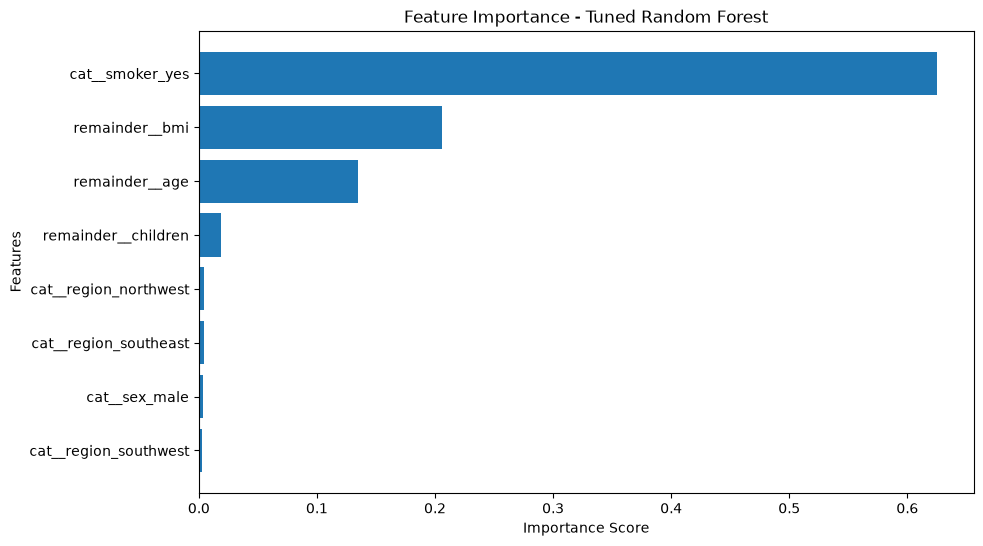

In [21]:
# ==========================
# Feature Importance
# ==========================

import pandas as pd
import matplotlib.pyplot as plt

# Get feature names after preprocessing
feature_names = best_rf.named_steps["preprocessor"].get_feature_names_out()

# Get feature importance values
importance = best_rf.named_steps["model"].feature_importances_

# Create DataFrame
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

# Sort by importance
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(importance_df)

# Plot
plt.figure(figsize=(10,6))
plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.title("Feature Importance - Tuned Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.gca().invert_yaxis()
plt.show()

# Conclusion

In this project, a machine learning pipeline was developed to predict medical insurance charges using demographic and health-related information.

The dataset was first explored using Exploratory Data Analysis (EDA) to understand feature distributions and relationships with the target variable. Missing values and duplicate records were checked before preprocessing the data.

Categorical variables were encoded using a `ColumnTransformer` with `OneHotEncoder`, and the preprocessing step was integrated with different regression algorithms using Scikit-learn's `Pipeline`. This approach ensured that preprocessing was performed correctly during both training and prediction while preventing data leakage.

The following regression models were trained and evaluated:

- Linear Regression
- Ridge Regression
- Lasso Regression
- Decision Tree Regressor
- Random Forest Regressor

The models were compared using R² Score, Mean Absolute Error (MAE), Mean Squared Error (MSE), and Root Mean Squared Error (RMSE).

Among all the models, the **Tuned Random Forest Regressor** achieved the best performance with:

- **R² Score:** 0.8878
- **MAE:** 2580.77
- **RMSE:** 4540.78

Hyperparameter tuning using GridSearchCV further improved the model's predictive performance. Feature importance analysis showed that **smoking status** was the most influential factor affecting insurance charges, followed by **BMI** and **age**.

Overall, the Tuned Random Forest Regressor was selected as the final model because it provided the highest predictive accuracy and generalized well on unseen data.